# Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

#Setting to make numbers easier to read on display
pd.options.display.float_format ='{:20.2f}'.format

#Show all columns on output
pd.set_option('display.max_columns', 999)


# Data Exploration

In [3]:
df=pd.read_excel("./data/online_retail.xlsx",sheet_name=0)
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.00,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.00,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.00,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.00,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [5]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.00,525461,525461.00,417534.00
mean,10.34,2010-06-28 11:37:36.845017856,4.69,15360.65
min,-9600.00,2009-12-01 07:45:00,-53594.36,12346.00
25%,1.00,2010-03-21 12:20:00,1.25,13983.00
50%,3.00,2010-07-06 09:51:00,2.10,15311.00
75%,10.00,2010-10-15 12:45:00,4.21,16799.00
max,19152.00,2010-12-09 20:01:00,25111.09,18287.00
std,107.42,NaN,146.13,1680.81


In [6]:
df.describe(include='O')

,Invoice,StockCode,Description,Country
count,525461,525461,522533,525461
unique,28816,4632,4681,40
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,675,3516,3549,485852


In [7]:
df[df["Customer ID"].isna()].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,2009-12-01 12:32:00,1.65,NaN,United Kingdom


In [8]:
df[df["Quantity"]<0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.00,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.00,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.00,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.00,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.00,United Kingdom


In [10]:
df["Invoice"]=df["Invoice"].astype(str) 
df[df["Invoice"].str.match("^\\d{6}$")==False]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.00,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
...,...,...,...,...,...,...,...,...
524695,C538123,22956,36 FOIL HEART CAKE CASES,-2,2010-12-09 15:41:00,2.10,12605.00,Germany
524696,C538124,M,Manual,-4,2010-12-09 15:43:00,0.50,15329.00,United Kingdom
524697,C538124,22699,ROSES REGENCY TEACUP AND SAUCER,-1,2010-12-09 15:43:00,2.95,15329.00,United Kingdom
524698,C538124,22423,REGENCY CAKESTAND 3 TIER,-1,2010-12-09 15:43:00,12.75,15329.00,United Kingdom


In [11]:
df["Invoice"].str.replace("[0-9]","",regex=True).unique()

array(['', 'C', 'A'], dtype=object)

In [12]:
df[df["Invoice"].str.startswith("A")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [15]:
df["StockCode"]=df["StockCode"].astype(str)
df[(df["StockCode"].str.match("^\\d{5}$")==False) & (df["StockCode"].str.match("^\\d{5}[a-zA-Z]+$")==False)]["StockCode"].unique()

array(['POST', 'D', 'DCGS0058', 'DCGS0068', 'DOT', 'M', 'DCGS0004',
       'DCGS0076', 'C2', 'BANK CHARGES', 'DCGS0003', 'TEST001',
       'gift_0001_80', 'DCGS0072', 'gift_0001_20', 'DCGS0044', 'TEST002',
       'gift_0001_10', 'gift_0001_50', 'DCGS0066N', 'gift_0001_30',
       'PADS', 'ADJUST', 'gift_0001_40', 'gift_0001_60', 'gift_0001_70',
       'gift_0001_90', 'DCGSSGIRL', 'DCGS0006', 'DCGS0016', 'DCGS0027',
       'DCGS0036', 'DCGS0039', 'DCGS0060', 'DCGS0056', 'DCGS0059', 'GIFT',
       'DCGSLBOY', 'm', 'DCGS0053', 'DCGS0062', 'DCGS0037', 'DCGSSBOY',
       'DCGSLGIRL', 'S', 'DCGS0069', 'DCGS0070', 'DCGS0075', 'B',
       'DCGS0041', 'ADJUST2', '47503J ', 'C3', 'SP1002', 'AMAZONFEE'],
      dtype=object)

In [16]:
df[df["StockCode"].str.contains("^DOT")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
2379,489597,DOT,DOTCOM POSTAGE,1,2009-12-01 14:28:00,647.19,NaN,United Kingdom
2539,489600,DOT,DOTCOM POSTAGE,1,2009-12-01 14:43:00,55.96,NaN,United Kingdom
2551,489601,DOT,DOTCOM POSTAGE,1,2009-12-01 14:44:00,68.39,NaN,United Kingdom
2571,489602,DOT,DOTCOM POSTAGE,1,2009-12-01 14:45:00,59.35,NaN,United Kingdom
2619,489603,DOT,DOTCOM POSTAGE,1,2009-12-01 14:46:00,42.39,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
524272,538071,DOT,DOTCOM POSTAGE,1,2010-12-09 14:09:00,885.94,NaN,United Kingdom
524887,538148,DOT,DOTCOM POSTAGE,1,2010-12-09 16:26:00,547.32,NaN,United Kingdom
525000,538149,DOT,DOTCOM POSTAGE,1,2010-12-09 16:27:00,620.68,NaN,United Kingdom
525126,538153,DOT,DOTCOM POSTAGE,1,2010-12-09 16:31:00,822.94,NaN,United Kingdom


### Notes

#### Stock Code
* StockCode is meant to follow the pattern `[0-9]{5}` but seems to have legit values for `[0-9]{5}[a-zA-Z]+`
    * Also contains other values:
        | **Code**            | **Description**                                                        | **Action**              |
        |---------------------|------------------------------------------------------------------------|-------------------------|
        | DCGS            | Looks valid, some quantities are negative though and customer ID is null | Exclude from clustering |
        | D               | Looks valid, represents discount values                                | Exclude from clustering |
        | DOT             | Looks valid, represents postage charges                                | Exclude from clustering |
        | M or m          | Looks valid, represents manual transactions                            | Exclude from clustering |
        | C2              | Carriage transaction - not sure what this means                        | Exclude from clustering |
        | C3              | Not sure, only 1 transaction                                           | Exclude                 |
        | BANK CHARGES or B | Bank charges                                                        | Exclude from clustering |
        | S               | Samples sent to customer                                               | Exclude from clustering |
        | TESTXXX         | Testing data, not valid                                                | Exclude from clustering |
        | gift__XXX       | Purchases with gift cards, might be interesting for another analysis, but no customer data | Exclude |
        | PADS            | Looks like a legit stock code for padding                              | Include                 |
        | SP1002          | Looks like a special request item, only 2 transactions, 3 look legit, 1 has 0 pricing | Exclude for now|
        | AMAZONFEE       | Looks like fees for Amazon shipping or something                       | Exclude for now         |
        | ADJUSTX         | Looks like manual account adjustments by admins                        | Exclude for now         |

# Data Cleaning

In [19]:
cleaned_df=df.copy()


In [20]:
cleaned_df["Invoice"]=cleaned_df["Invoice"].astype("str")

mask=(cleaned_df["Invoice"].str.match("^\\d{6}$")==True)
cleaned_df=cleaned_df[mask]
cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.00,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.00,United Kingdom


In [23]:
cleaned_df["StockCode"]=cleaned_df["StockCode"].astype("str")
mask = (
    (cleaned_df["StockCode"].str.match("^\\d{5}$")==True)
|(cleaned_df["StockCode"].str.match("^\\d{5}[a-zA-Z]+$")==True)
|(cleaned_df["StockCode"].str.contains("^PADS$")==True)
)
cleaned_df=cleaned_df[mask]
cleaned_df

C:\Users\21626\AppData\Local\Temp\ipykernel_23636\3736002303.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df["StockCode"]=cleaned_df["StockCode"].astype("str")


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.00,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.00,United Kingdom


In [25]:
cleaned_df.dropna(subset=["Customer ID"],inplace=True)

In [26]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,406337.00,406337,406337.00,406337.00
mean,13.62,2010-07-01 10:11:06.543288320,2.99,15373.63
min,1.00,2009-12-01 07:45:00,0.00,12346.00
25%,2.00,2010-03-26 14:01:00,1.25,14004.00
50%,5.00,2010-07-09 15:48:00,1.95,15326.00
75%,12.00,2010-10-14 17:09:00,3.75,16814.00
max,19152.00,2010-12-09 20:01:00,295.00,18287.00
std,97.00,NaN,4.29,1677.37


In [32]:
len(cleaned_df[cleaned_df["Price"]==0])

0

In [29]:
cleaned_df=cleaned_df[cleaned_df["Price"]>0]

In [30]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,406309.00,406309,406309.00,406309.00
mean,13.62,2010-07-01 10:14:25.869572352,2.99,15373.72
min,1.00,2009-12-01 07:45:00,0.00,12346.00
25%,2.00,2010-03-26 14:01:00,1.25,14006.00
50%,5.00,2010-07-09 15:48:00,1.95,15326.00
75%,12.00,2010-10-14 17:09:00,3.75,16814.00
max,19152.00,2010-12-09 20:01:00,295.00,18287.00
std,97.00,NaN,4.29,1677.33


In [31]:
cleaned_df["Price"].min()

0.001

In [33]:
len(cleaned_df)/len(df)

0.7732429238325965

Droped about 23% of records

# Feature Engineering


In [34]:
cleaned_df["SalesLineTotal"]=cleaned_df["Quantity"]*cleaned_df["Price"]
cleaned_df

C:\Users\21626\AppData\Local\Temp\ipykernel_23636\926273082.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df["SalesLineTotal"]=cleaned_df["Quantity"]*cleaned_df["Price"]


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SalesLineTotal
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.00,United Kingdom,5.90
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom,3.75
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom,3.75
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.00,United Kingdom,7.50


In [41]:
aggregated_df=cleaned_df.groupby(by="Customer ID",as_index=False)\
    .agg(
        MonetaryValue=("SalesLineTotal","sum"),
        Frequency=("Invoice","nunique"),
        LastInvoiceDate=("InvoiceDate","max"))
aggregated_df.head(5)

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate
0,12346.00,169.36,2,2010-06-28 13:53:00
1,12347.00,1323.32,2,2010-12-07 14:57:00
2,12348.00,221.16,1,2010-09-27 14:59:00
3,12349.00,2221.14,2,2010-10-28 08:23:00
4,12351.00,300.93,1,2010-11-29 15:23:00


In [43]:
max_invoice_date=aggregated_df["LastInvoiceDate"].max()
aggregated_df["Recency"]=(max_invoice_date-aggregated_df["LastInvoiceDate"]).dt.days
aggregated_df.head(5)

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
0,12346.00,169.36,2,2010-06-28 13:53:00,164
1,12347.00,1323.32,2,2010-12-07 14:57:00,2
2,12348.00,221.16,1,2010-09-27 14:59:00,73
3,12349.00,2221.14,2,2010-10-28 08:23:00,42
4,12351.00,300.93,1,2010-11-29 15:23:00,10


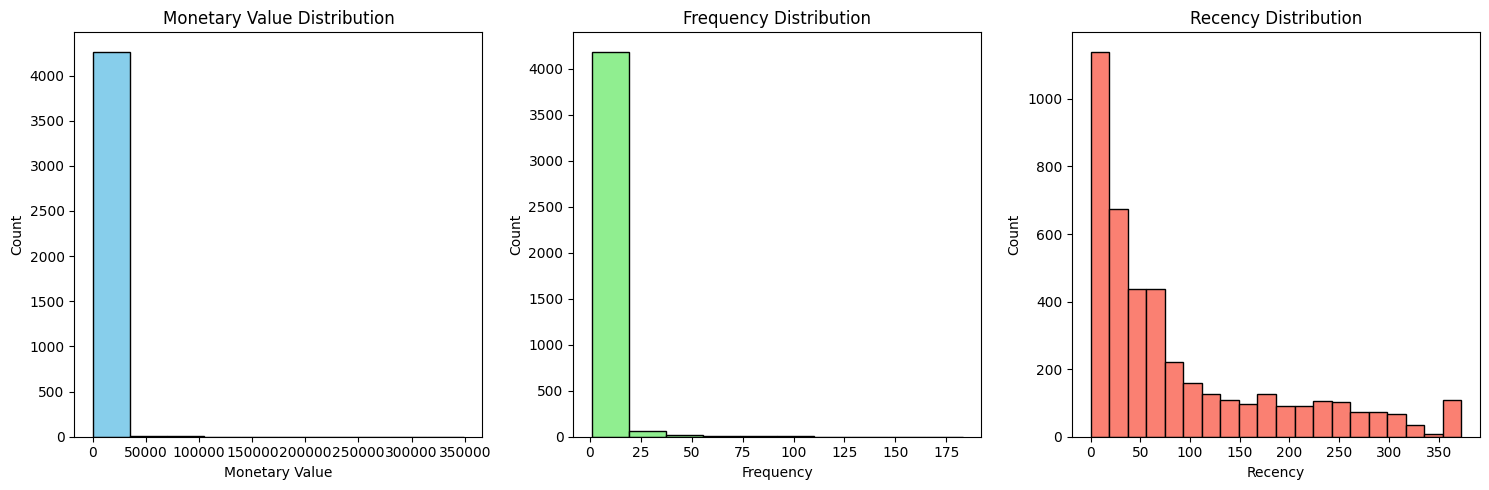

In [47]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(aggregated_df['MonetaryValue'], bins=10, color='skyblue', edgecolor='black')
plt.title('Monetary Value Distribution')
plt.xlabel('Monetary Value')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
plt.hist(aggregated_df['Frequency'], bins=10, color='lightgreen', edgecolor='black')
plt.title('Frequency Distribution')
plt.xlabel('Frequency')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
plt.hist(aggregated_df["Recency"], bins=20, color='salmon', edgecolor='black')
plt.title('Recency Distribution')
plt.xlabel('Recency')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

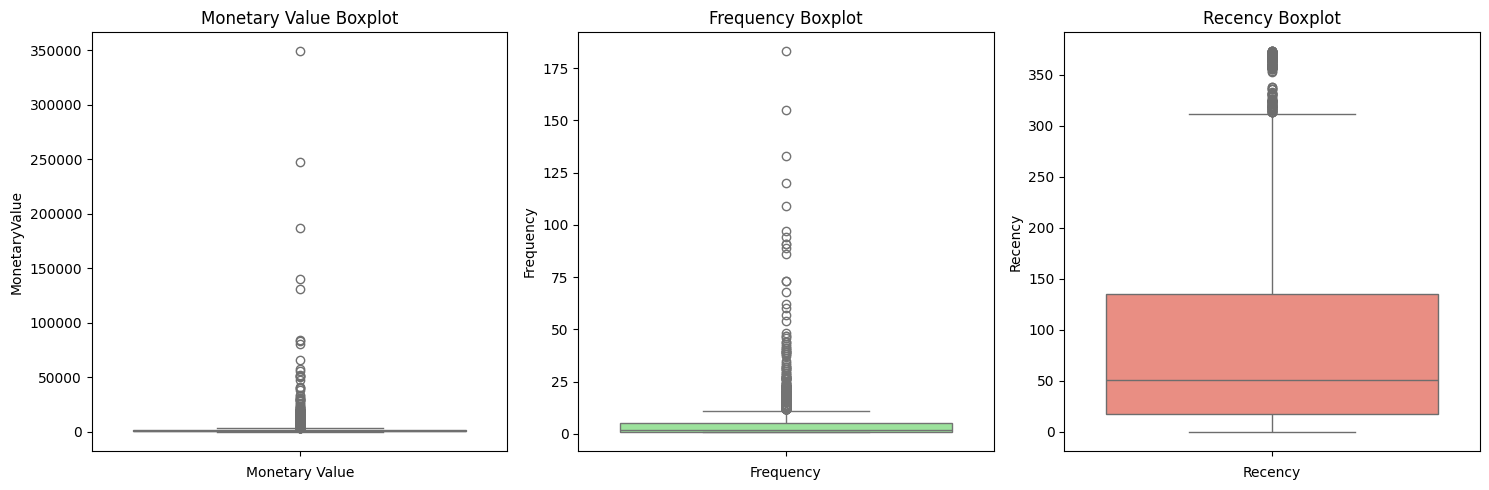

In [48]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=aggregated_df['MonetaryValue'], color='skyblue')
plt.title('Monetary Value Boxplot')
plt.xlabel('Monetary Value')

plt.subplot(1, 3, 2)
sns.boxplot(data=aggregated_df['Frequency'], color='lightgreen')
plt.title('Frequency Boxplot')
plt.xlabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(data=aggregated_df['Recency'], color='salmon')
plt.title('Recency Boxplot')
plt.xlabel('Recency')

plt.tight_layout()
plt.show()

In [50]:
M_Q1=aggregated_df["MonetaryValue"].quantile(0.25)
M_Q3=aggregated_df["MonetaryValue"].quantile(0.75)
M_IQR=M_Q3-M_Q1

monetary_outliers_df=aggregated_df[(aggregated_df["MonetaryValue"]>(M_Q3+1.5*M_IQR))|(aggregated_df["MonetaryValue"]<(M_Q1-1.5*M_IQR))].copy()
monetary_outliers_df.describe()


,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,423.00,423.00,423.00,423,423.00
mean,15103.04,12188.10,17.17,2010-11-09 12:26:02.978723328,30.04
min,12357.00,3802.04,1.00,2009-12-10 18:03:00,0.00
25%,13622.00,4605.94,8.00,2010-11-08 13:17:30,3.00
50%,14961.00,6191.32,12.00,2010-11-26 12:19:00,13.00
75%,16692.00,10273.24,18.00,2010-12-06 10:34:30,31.00
max,18260.00,349164.35,183.00,2010-12-09 19:32:00,364.00
std,1728.66,25830.85,19.73,NaN,51.54


In [51]:
F_Q1=aggregated_df["Frequency"].quantile(0.25)
F_Q3=aggregated_df["Frequency"].quantile(0.75)
F_IQR=F_Q3-F_Q1

frequency_outliers_df=aggregated_df[(aggregated_df["Frequency"]>(F_Q3+1.5*F_IQR))|(aggregated_df["Frequency"]<(F_Q1-1.5*F_IQR))].copy()
frequency_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,279.00,279.00,279.00,279,279.00
mean,15352.66,14409.71,23.81,2010-11-23 11:06:20.645161216,16.09
min,12437.00,1094.39,12.00,2010-05-12 16:51:00,0.00
25%,13800.00,4331.56,13.00,2010-11-20 13:14:30,2.00
50%,15465.00,6615.77,17.00,2010-12-02 10:46:00,7.00
75%,16828.50,11692.41,23.00,2010-12-07 11:08:30,19.00
max,18260.00,349164.35,183.00,2010-12-09 19:32:00,211.00
std,1748.43,31381.74,21.93,NaN,26.59


In [52]:
non_outliers_df=aggregated_df[(~aggregated_df.index.isin(monetary_outliers_df.index))&(~aggregated_df.index.isin(frequency_outliers_df.index))]
non_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,3809.00,3809.00,3809.00,3809,3809.00
mean,15376.48,885.50,2.86,2010-09-03 11:16:46.516146176,97.08
min,12346.00,1.55,1.00,2009-12-01 10:49:00,0.00
25%,13912.00,279.91,1.00,2010-07-08 14:48:00,22.00
50%,15389.00,588.05,2.00,2010-10-12 16:25:00,58.00
75%,16854.00,1269.05,4.00,2010-11-17 13:14:00,154.00
max,18287.00,3788.21,11.00,2010-12-09 20:01:00,373.00
std,1693.20,817.67,2.24,NaN,98.11


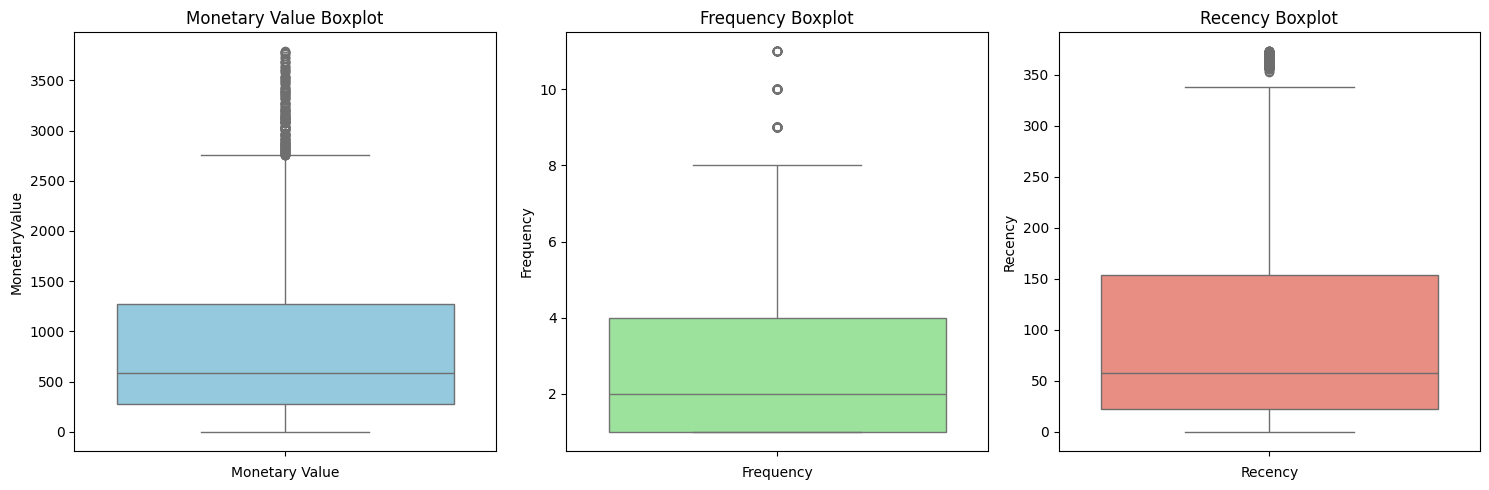

In [53]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=non_outliers_df['MonetaryValue'], color='skyblue')
plt.title('Monetary Value Boxplot')
plt.xlabel('Monetary Value')

plt.subplot(1, 3, 2)
sns.boxplot(data=non_outliers_df['Frequency'], color='lightgreen')
plt.title('Frequency Boxplot')
plt.xlabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(data=non_outliers_df['Recency'], color='salmon')
plt.title('Recency Boxplot')
plt.xlabel('Recency')

plt.tight_layout()
plt.show()

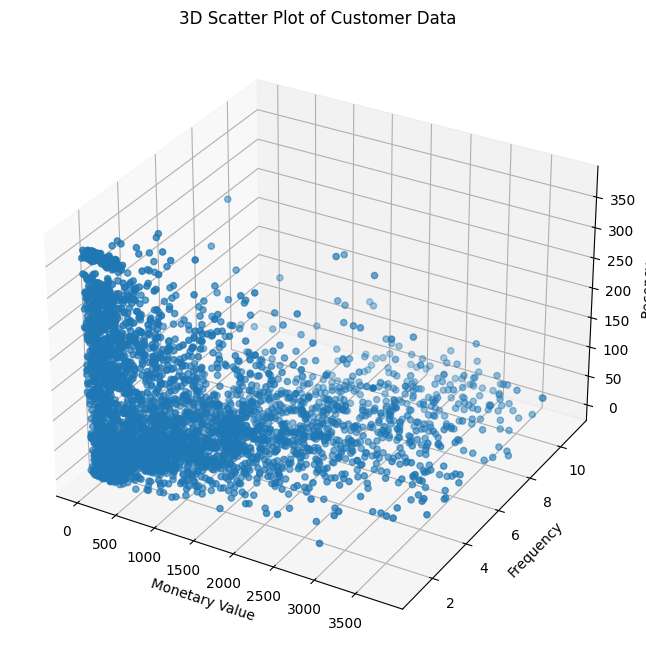

In [54]:
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(projection="3d")

scatter = ax.scatter(non_outliers_df["MonetaryValue"], non_outliers_df["Frequency"], non_outliers_df["Recency"])

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

ax.set_title('3D Scatter Plot of Customer Data')

plt.show()

In [55]:
scaler = StandardScaler()
scaled_data=scaler.fit_transform(non_outliers_df[["MonetaryValue","Frequency","Recency"]])
scaled_data

array([[-0.87594534, -0.38488934,  0.68214853],
       [ 0.5355144 , -0.38488934, -0.96925093],
       [-0.81258645, -0.83063076, -0.24548944],
       ...,
       [-0.62197163, -0.83063076,  2.01753946],
       [ 0.44146683, -0.38488934,  0.14187587],
       [ 1.72488781,  0.50659348, -0.81634357]])

In [56]:
scaled_data_df=pd.DataFrame(scaled_data,index=non_outliers_df.index,columns=["MonetaryValue","Frequency","Recency"]) 
scaled_data_df

,MonetaryValue,Frequency,Recency
0,-0.88,-0.38,0.68
1,0.54,-0.38,-0.97
2,-0.81,-0.83,-0.25
3,1.63,-0.38,-0.56
4,-0.72,-0.83,-0.89
...,...,...,...
4280,-0.30,1.40,-0.82
4281,-0.58,-0.83,-0.32
4282,-0.62,-0.83,2.02
4283,0.44,-0.38,0.14


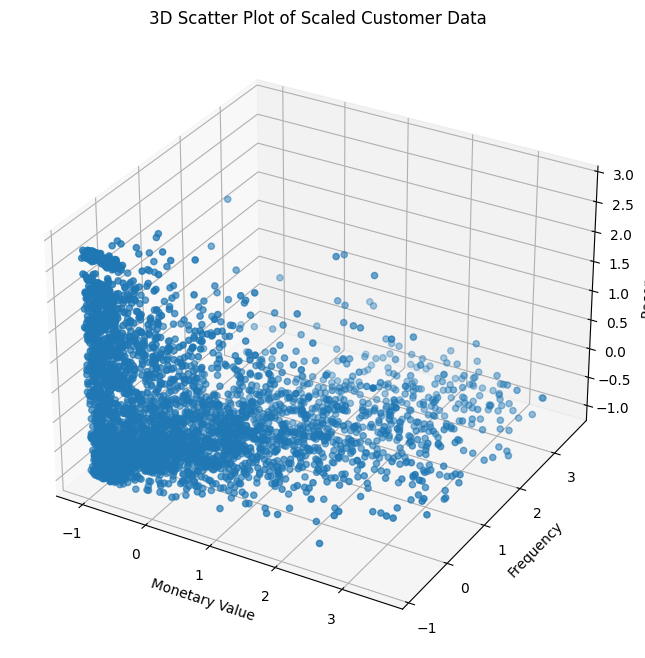

In [57]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection="3d")
scatter = ax.scatter(scaled_data_df["MonetaryValue"], scaled_data_df["Frequency"], scaled_data_df["Recency"])
ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')
ax.set_title('3D Scatter Plot of Scaled Customer Data')
plt.show()    

# KMeans Clustering

Elbow Method-silhouette scores

C:\Users\21626\AppData\Roaming\Python\Python38\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\21626\AppData\Roaming\Python\Python38\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\21626\AppData\Roaming\Python\Python38\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\21626\AppData\Roaming\Python\Python38\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default 

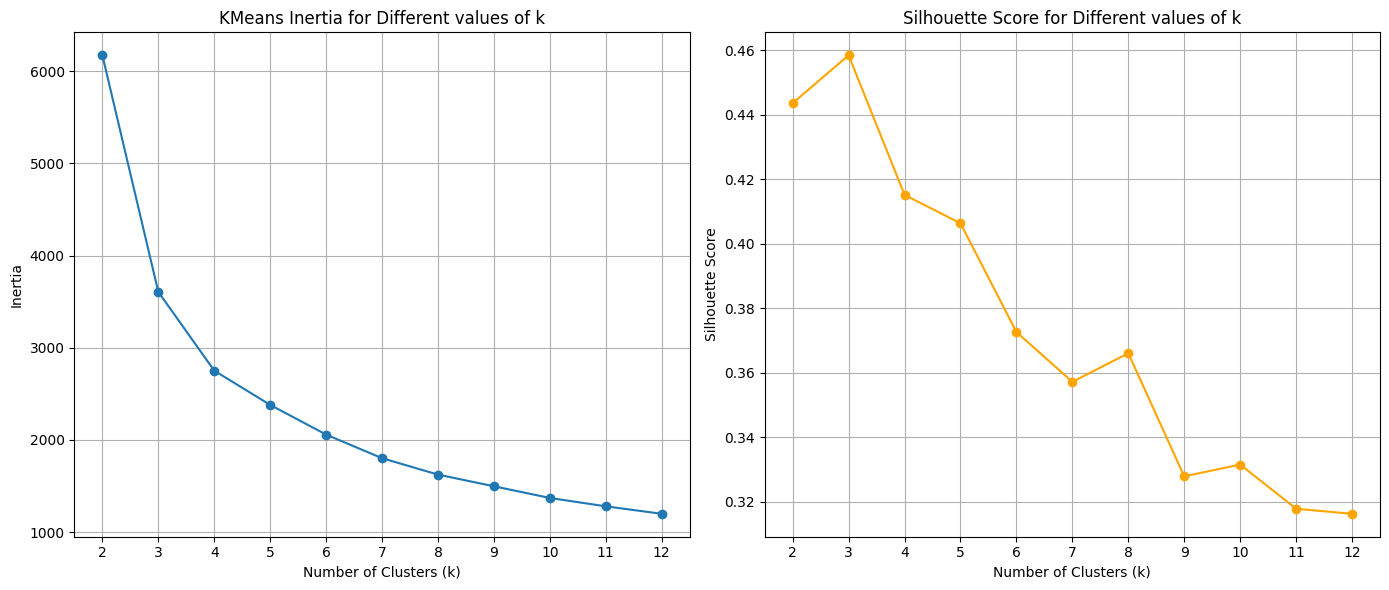

In [60]:
max_k=12
inertia=[]
silhouette_scores=[]
k_values=range(2,max_k + 1)

for k in k_values:
    kmeans=KMeans(n_clusters=k,random_state=42,max_iter=1000)

    cluster_labels=kmeans.fit_predict(scaled_data_df)
    sil_score=silhouette_score(scaled_data_df,cluster_labels)
    silhouette_scores.append(sil_score)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(14, 6))
plt.subplot(1,2,1)
plt.plot(k_values,inertia,marker='o')    
plt.title('KMeans Inertia for Different values of k')
plt.xlabel('Number of Clusters (k)')
plt.xticks(k_values)
plt.ylabel('Inertia')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(k_values,silhouette_scores,marker='o',color='orange')
plt.title('Silhouette Score for Different values of k')
plt.xlabel('Number of Clusters (k)')
plt.xticks(k_values)
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.tight_layout()
plt.show()


In [62]:
kmeans=KMeans(n_clusters=4,random_state=42,max_iter=1000)
cluster_labels=kmeans.fit_predict(scaled_data_df)
cluster_labels

C:\Users\21626\AppData\Roaming\Python\Python38\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


array([3, 0, 2, ..., 3, 0, 0])

In [63]:
non_outliers_df["Cluster"]=cluster_labels
non_outliers_df

C:\Users\21626\AppData\Local\Temp\ipykernel_23636\1086312508.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_outliers_df["Cluster"]=cluster_labels


,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
0,12346.00,169.36,2,2010-06-28 13:53:00,164,3
1,12347.00,1323.32,2,2010-12-07 14:57:00,2,0
2,12348.00,221.16,1,2010-09-27 14:59:00,73,2
3,12349.00,2221.14,2,2010-10-28 08:23:00,42,0
4,12351.00,300.93,1,2010-11-29 15:23:00,10,2
...,...,...,...,...,...,...
4280,18283.00,641.77,6,2010-11-22 15:30:00,17,0
4281,18284.00,411.68,1,2010-10-04 11:33:00,66,2
4282,18285.00,377.00,1,2010-02-17 10:24:00,295,3
4283,18286.00,1246.43,2,2010-08-20 11:57:00,111,0


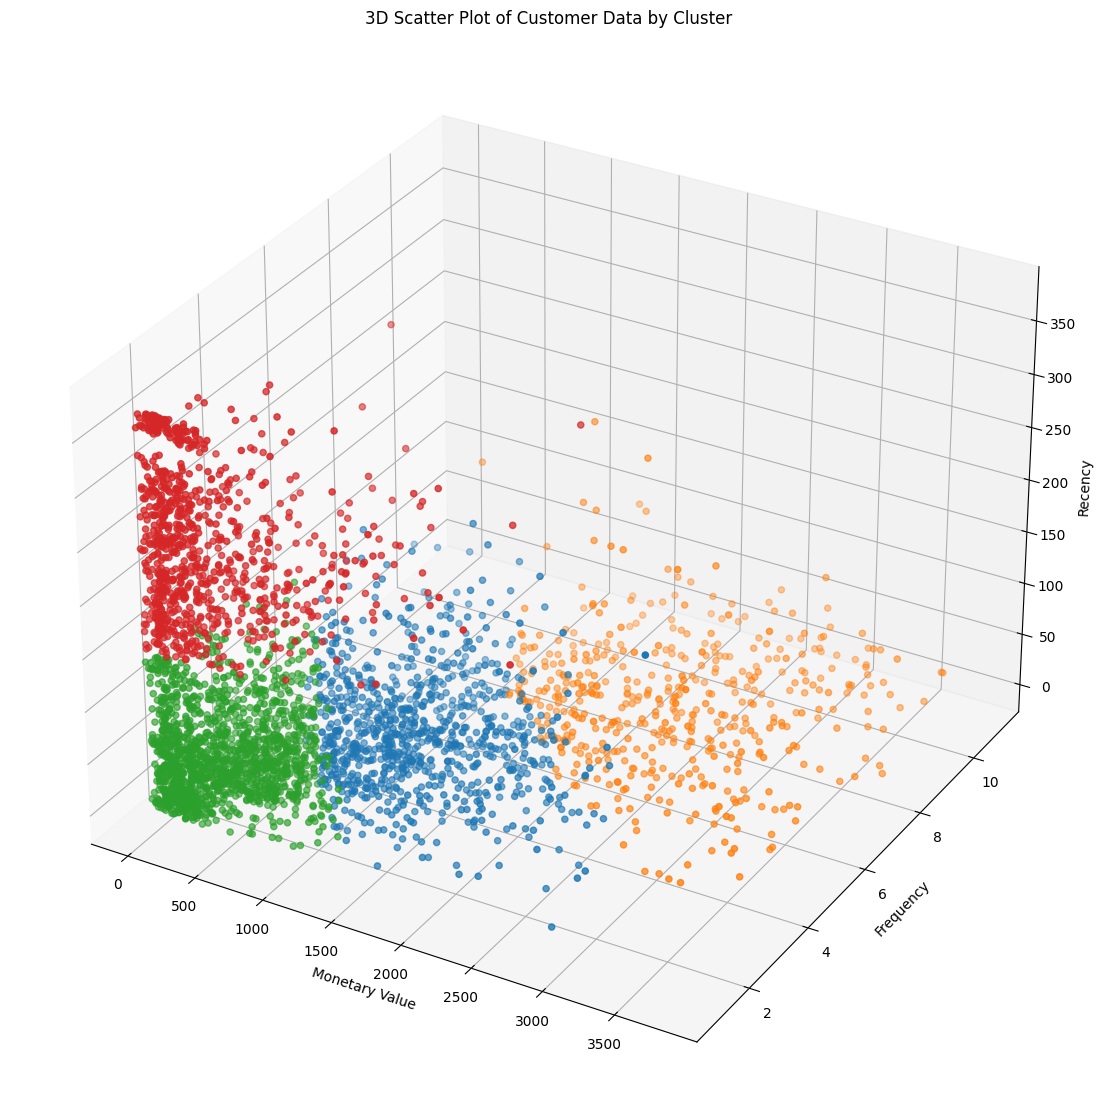

In [68]:
cluster_colors = {0: '#1f77b4',  # Blue
                  1: '#ff7f0e',  # Orange
                  2: '#2ca02c',  # Green
                  3: '#d62728'}  # Red

colors = non_outliers_df['Cluster'].map(cluster_colors)

fig = plt.figure(figsize=(15, 14))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(non_outliers_df['MonetaryValue'], 
                     non_outliers_df['Frequency'], 
                     non_outliers_df['Recency'], 
                     c=colors,  # Use mapped solid colors
                     marker='o')

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

ax.set_title('3D Scatter Plot of Customer Data by Cluster')

plt.show()

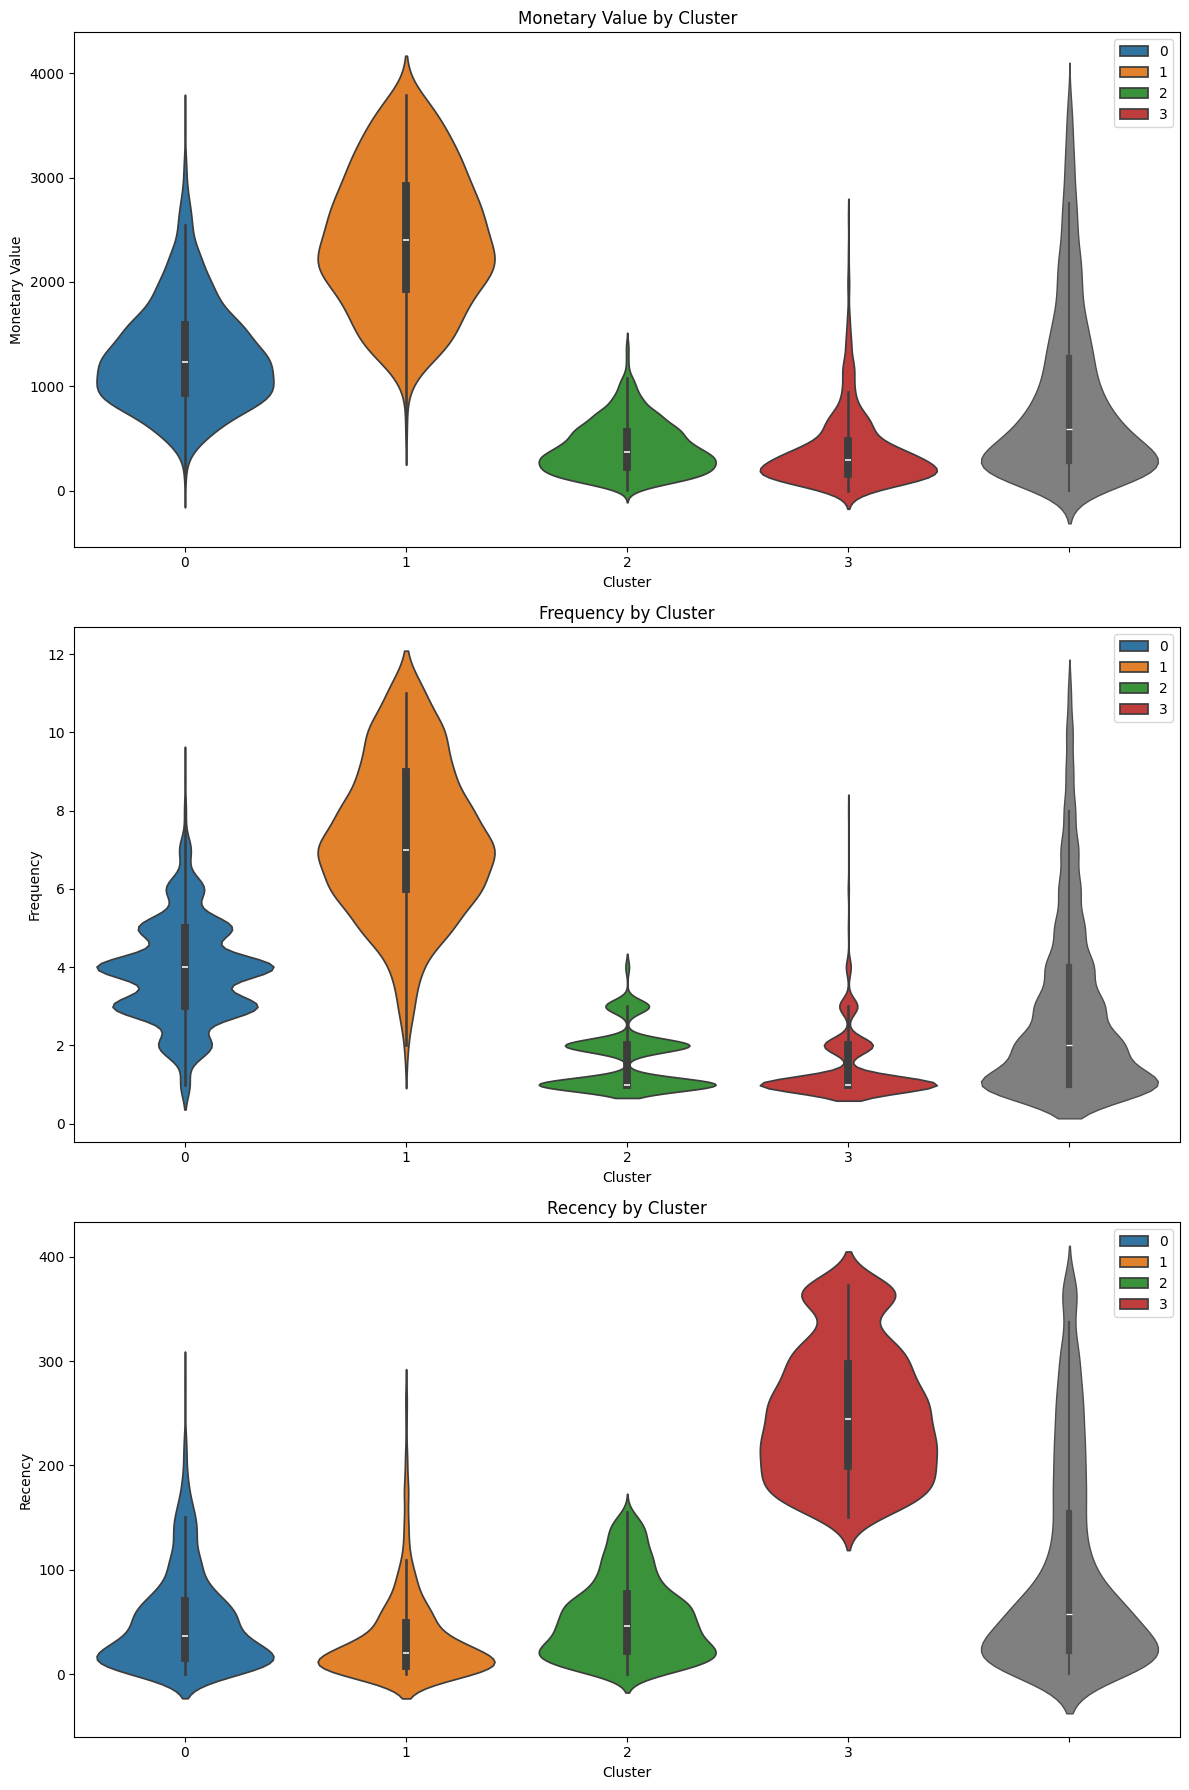

In [69]:
plt.figure(figsize=(12, 18))

plt.subplot(3, 1, 1)
sns.violinplot(x=non_outliers_df['Cluster'], y=non_outliers_df['MonetaryValue'], palette=cluster_colors, hue=non_outliers_df["Cluster"])
sns.violinplot(y=non_outliers_df['MonetaryValue'], color='gray', linewidth=1.0)
plt.title('Monetary Value by Cluster')
plt.ylabel('Monetary Value')

plt.subplot(3, 1, 2)
sns.violinplot(x=non_outliers_df['Cluster'], y=non_outliers_df['Frequency'], palette=cluster_colors, hue=non_outliers_df["Cluster"])
sns.violinplot(y=non_outliers_df['Frequency'], color='gray', linewidth=1.0)
plt.title('Frequency by Cluster')
plt.ylabel('Frequency')


plt.subplot(3, 1, 3)
sns.violinplot(x=non_outliers_df['Cluster'], y=non_outliers_df['Recency'], palette=cluster_colors, hue=non_outliers_df["Cluster"])
sns.violinplot(y=non_outliers_df['Recency'], color='gray', linewidth=1.0)
plt.title('Recency by Cluster')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()

1. Cluster 0 — Blue: Loyal / Regular Customers

Rationale:
This cluster represents customers with moderate monetary value and regular purchasing behavior. Their purchase frequency is higher than that of Cluster 2 and Cluster 3, while their recency remains relatively low, indicating that they have purchased fairly recently.

Action:
Focus on retention and engagement strategies, such as personalized recommendations, loyalty rewards, and targeted promotions to maintain their purchasing activity and gradually increase their spending.

2. Cluster 1 — Orange: High-Value Customers

Rationale:
This cluster represents the highest-value customers in the dataset. They have the highest Monetary Value and Frequency, while also having a relatively low Recency. This indicates customers who purchase frequently, spend significantly more, and have been active relatively recently.

Action:
These customers should receive VIP treatment and exclusive rewards. Offer premium loyalty programs, personalized offers, early access to products, and exclusive promotions to maximize their long-term value and prevent churn.

3. Cluster 2 — Green: Nurture / Emerging Customers

Rationale:
This cluster contains customers with low Monetary Value and low Frequency, but their Recency is relatively low. This means they have purchased recently, but they have not yet developed strong purchasing habits or high spending levels.

Action:
Focus on nurturing these customers by encouraging repeat purchases through personalized recommendations, introductory offers, and targeted promotions. The objective is to gradually increase their frequency and monetary value.

4. Cluster 3 — Red: At-Risk / Re-Engage Customers

Rationale:
This cluster is characterized by low Monetary Value and low Frequency, combined with a very high Recency. These customers have not purchased for a long period of time and therefore represent the group most at risk of becoming inactive or lost.

Action:
Launch re-engagement campaigns using personalized discounts, reminders, special offers, or win-back campaigns to encourage them to return and make another purchase.
Summary of Cluster Names
Cluster 0 (Blue): Loyal / Regular
Cluster 1 (Orange): High-Value / VIP
Cluster 2 (Green): Nurture / Emerging
Cluster 3 (Red): At-Risk / Re-Engage


In [70]:
overlap_indices=monetary_outliers_df.index.intersection(frequency_outliers_df.index)
monetary_only_outliers=monetary_outliers_df.drop(overlap_indices)
frequency_only_outliers=frequency_outliers_df.drop(overlap_indices)
monetary_and_frequency_outliers=monetary_outliers_df.loc[overlap_indices]

monetary_only_outliers["Cluster"]=-1
frequency_only_outliers["Cluster"]=-2
monetary_and_frequency_outliers["Cluster"]=-3
outlier_clusters_df=pd.concat([monetary_only_outliers,frequency_only_outliers,monetary_and_frequency_outliers])
outlier_clusters_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
9,12357.00,11229.99,1,2010-11-16 10:05:00,23,-1
25,12380.00,4782.84,4,2010-08-31 14:54:00,100,-1
42,12409.00,12346.62,4,2010-10-15 10:24:00,55,-1
48,12415.00,19468.84,4,2010-11-29 15:07:00,10,-1
61,12431.00,4145.52,11,2010-12-01 10:03:00,8,-1
...,...,...,...,...,...,...
4235,18223.00,7516.31,12,2010-11-17 12:20:00,22,-3
4236,18225.00,7545.14,15,2010-12-09 15:46:00,0,-3
4237,18226.00,6650.83,15,2010-11-26 15:51:00,13,-3
4241,18231.00,4791.80,23,2010-10-29 14:17:00,41,-3


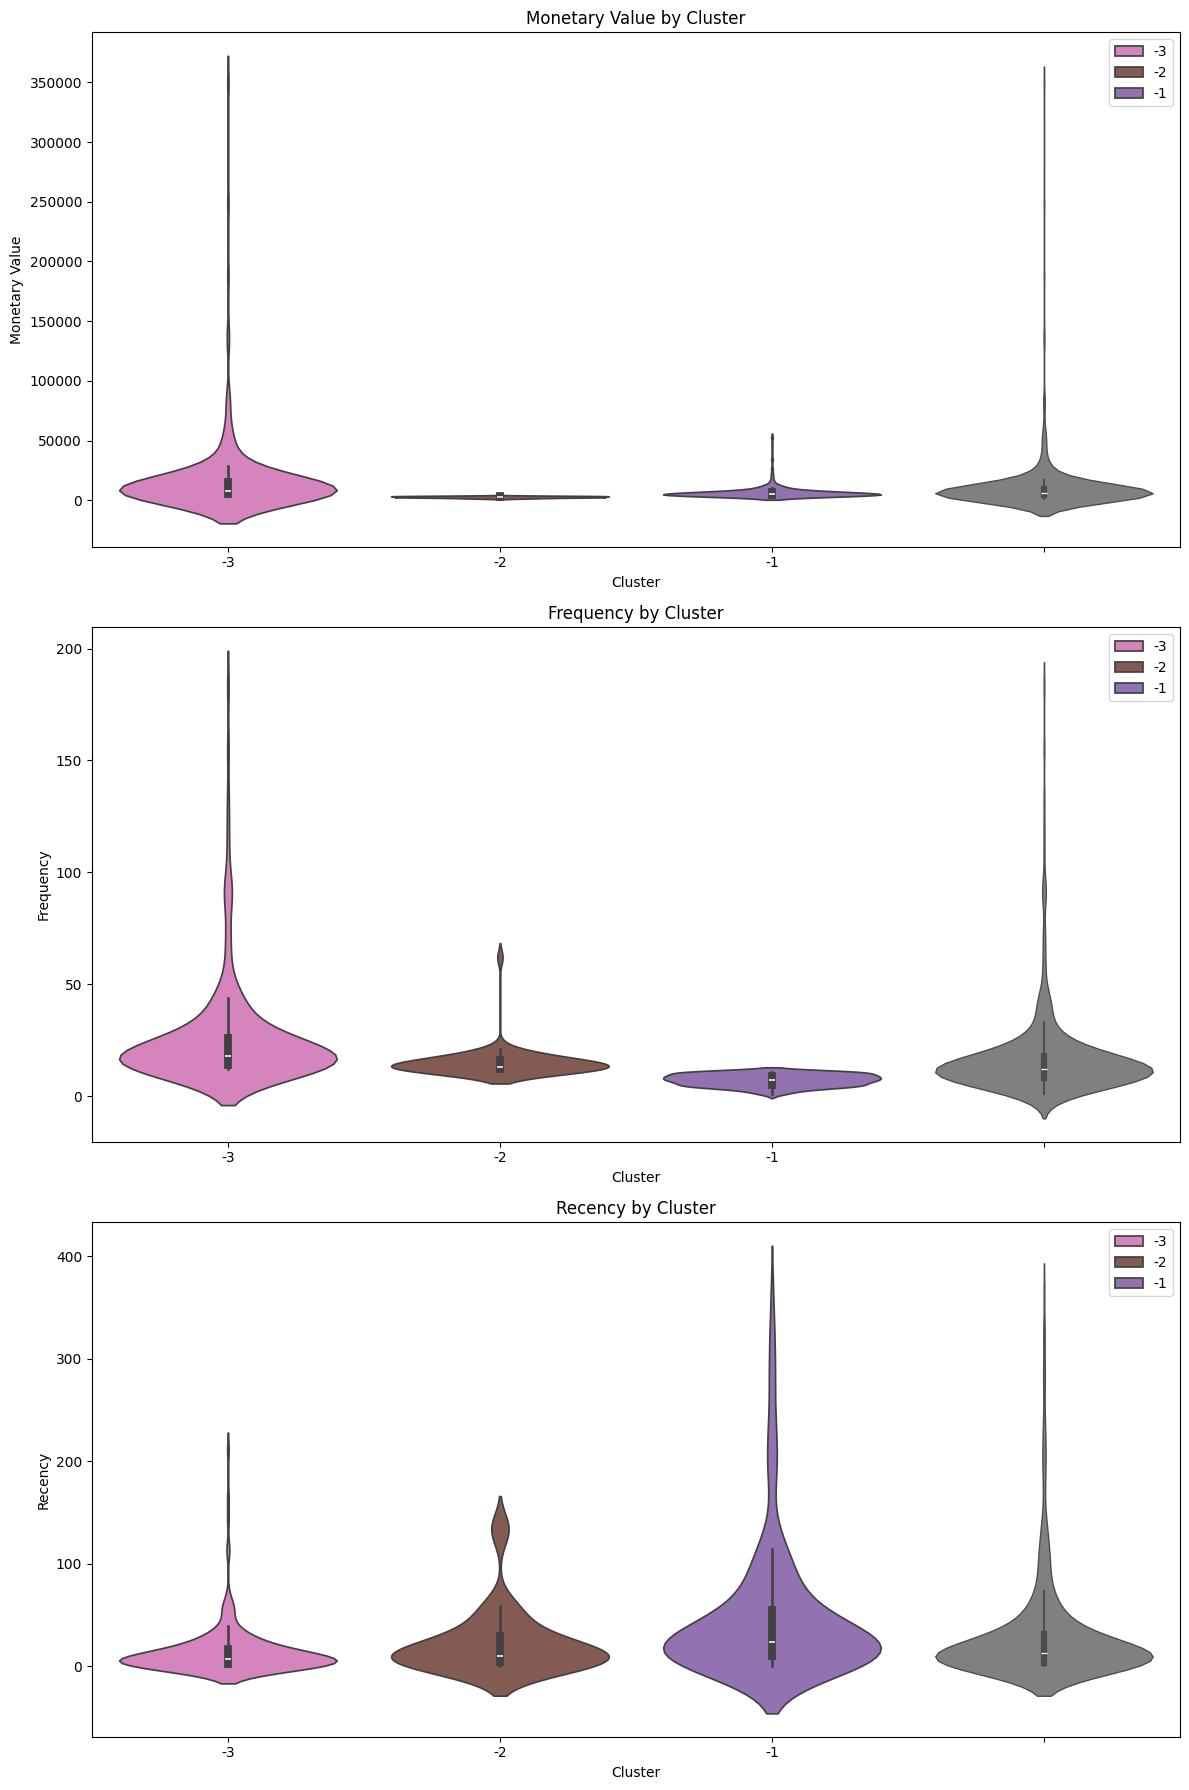

In [71]:
cluster_colors = {-1: '#9467bd',
                  -2: '#8c564b',
                  -3: '#e377c2'}

plt.figure(figsize=(12, 18))

plt.subplot(3, 1, 1)
sns.violinplot(x=outlier_clusters_df['Cluster'], y=outlier_clusters_df['MonetaryValue'], palette=cluster_colors, hue=outlier_clusters_df["Cluster"])
sns.violinplot(y=outlier_clusters_df['MonetaryValue'], color='gray', linewidth=1.0)
plt.title('Monetary Value by Cluster')
plt.ylabel('Monetary Value')

plt.subplot(3, 1, 2)
sns.violinplot(x=outlier_clusters_df['Cluster'], y=outlier_clusters_df['Frequency'], palette=cluster_colors, hue=outlier_clusters_df["Cluster"])
sns.violinplot(y=outlier_clusters_df['Frequency'], color='gray', linewidth=1.0)
plt.title('Frequency by Cluster')
plt.ylabel('Frequency')

plt.subplot(3, 1, 3)
sns.violinplot(x=outlier_clusters_df['Cluster'], y=outlier_clusters_df['Recency'], palette=cluster_colors, hue=outlier_clusters_df["Cluster"])
sns.violinplot(y=outlier_clusters_df['Recency'], color='gray', linewidth=1.0)
plt.title('Recency by Cluster')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()

* Cluster -1 (Monetary Outliers) PAMPER:
Characteristics: High spenders but not necessarily frequent buyers. Their purchases are large but infrequent.
Potential Strategy: Focus on maintaining their loyalty with personalized offers or luxury services that cater to their high spending capacity.

* Cluster -2 (Frequency Outliers) UPSELL:
Characteristics: Frequent buyers who spend less per purchase. These customers are consistently engaged but might benefit from upselling opportunities.
Potential Strategy: Implement loyalty programs or bundle deals to encourage higher spending per visit, given their frequent engagement.

* Cluster -3 (Monetary & Frequency Outliers) DELIGHT:
Characteristics: The most valuable outliers, with extreme spending and frequent purchases. They are likely your top-tier customers who require special attention.
Potential Strategy: Develop VIP programs or exclusive offers to maintain their loyalty and encourage continued engagement.

In [72]:
cluster_labels = {
    0: "RETAIN",
    1: "RE-ENGAGE",
    2: "NURTURE",
    3: "REWARD",
    -1: "PAMPER",
    -2: "UPSELL",
    -3: "DELIGHT"
}

In [73]:
full_clustering_df = pd.concat([non_outliers_df, outlier_clusters_df])

full_clustering_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
0,12346.00,169.36,2,2010-06-28 13:53:00,164,3
1,12347.00,1323.32,2,2010-12-07 14:57:00,2,0
2,12348.00,221.16,1,2010-09-27 14:59:00,73,2
3,12349.00,2221.14,2,2010-10-28 08:23:00,42,0
4,12351.00,300.93,1,2010-11-29 15:23:00,10,2
...,...,...,...,...,...,...
4235,18223.00,7516.31,12,2010-11-17 12:20:00,22,-3
4236,18225.00,7545.14,15,2010-12-09 15:46:00,0,-3
4237,18226.00,6650.83,15,2010-11-26 15:51:00,13,-3
4241,18231.00,4791.80,23,2010-10-29 14:17:00,41,-3


In [74]:
full_clustering_df["ClusterLabel"] = full_clustering_df["Cluster"].map(cluster_labels)

full_clustering_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster,ClusterLabel
0,12346.00,169.36,2,2010-06-28 13:53:00,164,3,REWARD
1,12347.00,1323.32,2,2010-12-07 14:57:00,2,0,RETAIN
2,12348.00,221.16,1,2010-09-27 14:59:00,73,2,NURTURE
3,12349.00,2221.14,2,2010-10-28 08:23:00,42,0,RETAIN
4,12351.00,300.93,1,2010-11-29 15:23:00,10,2,NURTURE
...,...,...,...,...,...,...,...
4235,18223.00,7516.31,12,2010-11-17 12:20:00,22,-3,DELIGHT
4236,18225.00,7545.14,15,2010-12-09 15:46:00,0,-3,DELIGHT
4237,18226.00,6650.83,15,2010-11-26 15:51:00,13,-3,DELIGHT
4241,18231.00,4791.80,23,2010-10-29 14:17:00,41,-3,DELIGHT


# Visualisation

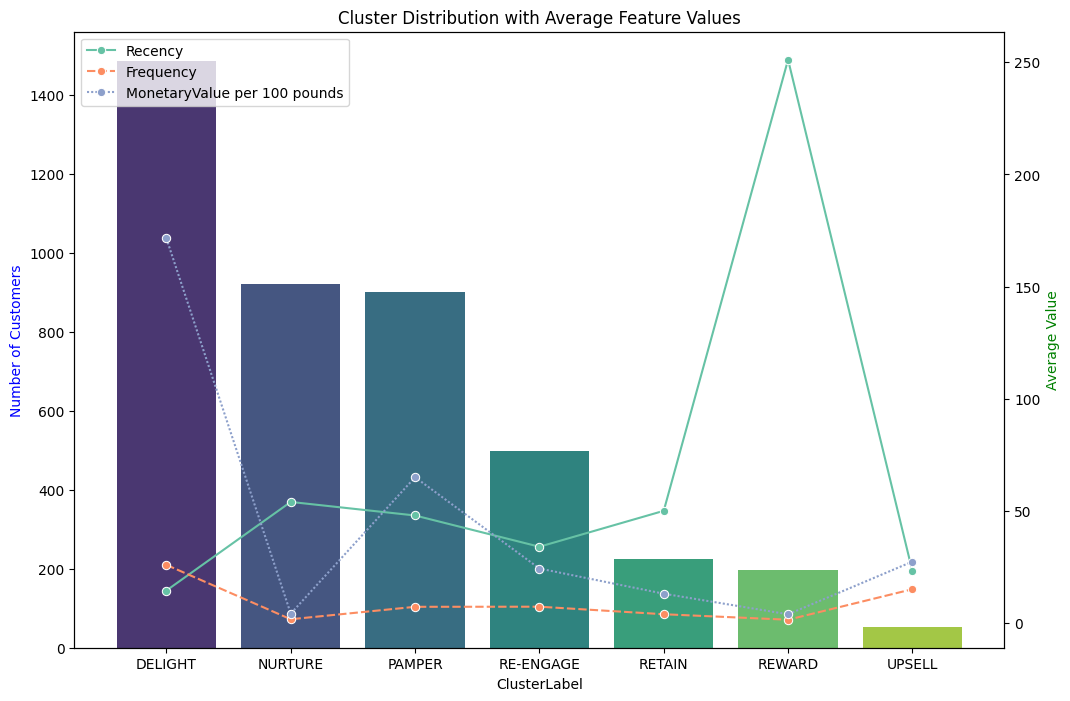

In [75]:
cluster_counts = full_clustering_df['ClusterLabel'].value_counts()
full_clustering_df["MonetaryValue per 100 pounds"] = full_clustering_df["MonetaryValue"] / 100.00
feature_means = full_clustering_df.groupby('ClusterLabel')[['Recency', 'Frequency', 'MonetaryValue per 100 pounds']].mean()

fig, ax1 = plt.subplots(figsize=(12, 8))

sns.barplot(x=cluster_counts.index, y=cluster_counts.values, ax=ax1, palette='viridis', hue=cluster_counts.index)
ax1.set_ylabel('Number of Customers', color='b')
ax1.set_title('Cluster Distribution with Average Feature Values')

ax2 = ax1.twinx()

sns.lineplot(data=feature_means, ax=ax2, palette='Set2', marker='o')
ax2.set_ylabel('Average Value', color='g')

plt.show()

# PCA/Dimensinality Reduction

In [76]:
from sklearn.decomposition import PCA

# Create the PCA model
pca = PCA(n_components=2)

# Apply PCA to the standardized RFM data
rfm_pca = pca.fit_transform(scaled_data)

# Create a DataFrame containing the two principal components
pca_df = pd.DataFrame(
    rfm_pca,
    columns=["PC1", "PC2"],
    index=non_outliers_df.index
)

pca_df.head()

,PC1,PC2
0,-1.10,0.17
1,0.53,-0.77
2,-0.92,-0.75
3,1.03,0.00
4,-0.57,-1.28


In [77]:
# Explained variance ratio of each principal component
explained_variance = pca.explained_variance_ratio_

# Display the explained variance
print("Explained variance ratio:")
print(f"PC1: {explained_variance[0]:.2%}")
print(f"PC2: {explained_variance[1]:.2%}")

# Total variance explained by the two components
total_variance = explained_variance.sum()

print(f"\nTotal variance explained by PC1 and PC2: {total_variance:.2%}")

Explained variance ratio:
PC1: 66.89%
PC2: 24.49%

Total variance explained by PC1 and PC2: 91.38%


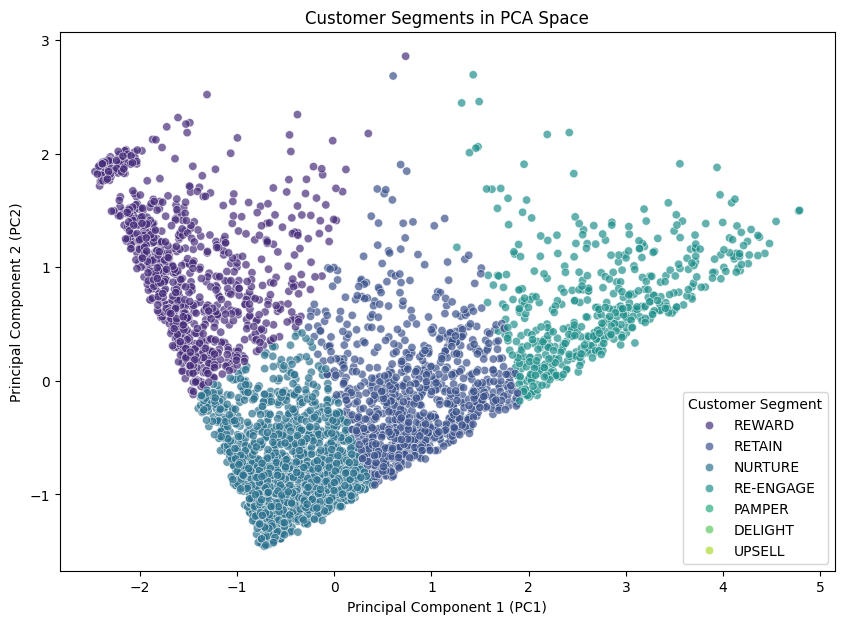

In [78]:
# Visualize the clusters in the PCA space

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue=full_clustering_df["ClusterLabel"],
    palette="viridis",
    alpha=0.7
)

plt.title("Customer Segments in PCA Space")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend(title="Customer Segment")
plt.show()

In [79]:
# Get the PCA loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=["Recency", "Frequency", "MonetaryValue"]
)

print("PCA Loadings:")
display(loadings)

PCA Loadings:


,PC1,PC2
Recency,0.62,0.37
Frequency,0.64,0.28
MonetaryValue,-0.46,0.89


In [ ]:
# Analyze the characteristics of each customer segment

cluster_summary = full_clustering_df.groupby("ClusterLabel").agg(
    Number_of_Customers=("ClusterLabel", "size"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_MonetaryValue=("MonetaryValue", "mean")
).round(2)

display(cluster_summary)

,Number_of_Customers,Avg_Recency,Avg_Frequency,Avg_MonetaryValue
ClusterLabel,,,,
DELIGHT,226,14.45,25.87,17147.66
NURTURE,1487,53.96,1.64,413.62
PAMPER,197,47.91,7.19,6498.45
RE-ENGAGE,499,33.98,7.24,2426.36
RETAIN,921,49.99,3.88,1303.17
REWARD,902,251.17,1.43,384.54
UPSELL,53,23.08,15.04,2734.69


In [81]:
# Analyze the revenue contribution of each customer segment

revenue_analysis = full_clustering_df.groupby("ClusterLabel").agg(
    Number_of_Customers=("ClusterLabel", "size"),
    Total_Revenue=("MonetaryValue", "sum"),
    Avg_Revenue_Per_Customer=("MonetaryValue", "mean")
)

# Calculate customer share
revenue_analysis["Customer_Share"] = (
    revenue_analysis["Number_of_Customers"]
    / revenue_analysis["Number_of_Customers"].sum()
    * 100
)

# Calculate revenue contribution
revenue_analysis["Revenue_Share"] = (
    revenue_analysis["Total_Revenue"]
    / revenue_analysis["Total_Revenue"].sum()
    * 100
)

# Round the results
revenue_analysis = revenue_analysis.round(2)

display(revenue_analysis)

,Number_of_Customers,Total_Revenue,Avg_Revenue_Per_Customer,Customer_Share,Revenue_Share
ClusterLabel,,,,,
DELIGHT,226,3875372.03,17147.66,5.27,44.68
NURTURE,1487,615053.22,413.62,34.70,7.09
PAMPER,197,1280195.01,6498.45,4.60,14.76
RE-ENGAGE,499,1210756.09,2426.36,11.65,13.96
RETAIN,921,1200216.50,1303.17,21.49,13.84
REWARD,902,346852.05,384.54,21.05,4.00
UPSELL,53,144938.44,2734.69,1.24,1.67


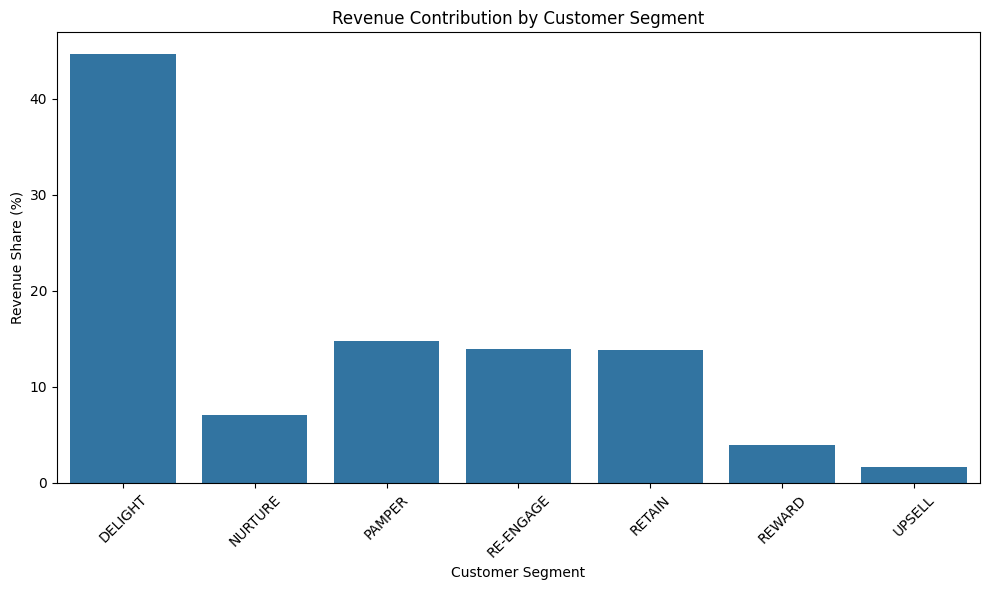

In [82]:
# Visualize revenue contribution by customer segment

plt.figure(figsize=(10, 6))

sns.barplot(
    data=revenue_analysis.reset_index(),
    x="ClusterLabel",
    y="Revenue_Share"
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue Share (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

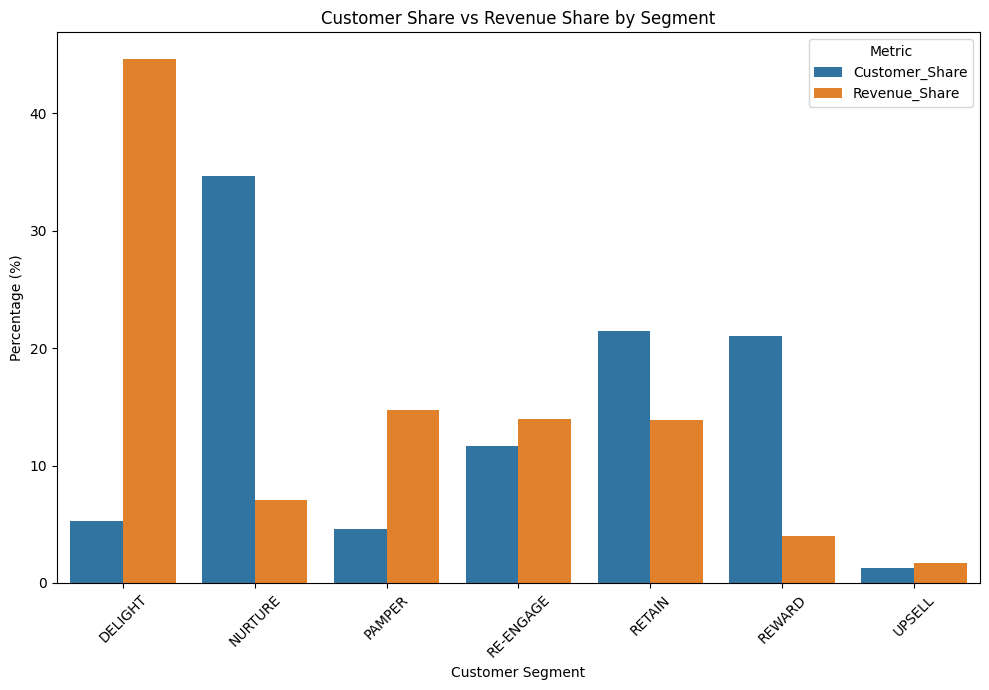

In [84]:
# Compare customer share and revenue share across segments

share_comparison = revenue_analysis[
    ["Customer_Share", "Revenue_Share"]
].reset_index()

share_comparison = share_comparison.melt(
    id_vars="ClusterLabel",
    value_vars=["Customer_Share", "Revenue_Share"],
    var_name="Metric",
    value_name="Percentage"
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=share_comparison,
    x="ClusterLabel",
    y="Percentage",
    hue="Metric"
)

plt.title("Customer Share vs Revenue Share by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [85]:
from sklearn.preprocessing import StandardScaler

scaler_profile = StandardScaler()

profile_data = cluster_summary[
    ["Avg_Recency", "Avg_Frequency", "Avg_MonetaryValue"]
].copy()

profile_scaled = scaler_profile.fit_transform(profile_data)

profile_data = pd.DataFrame(
    profile_scaled,
    columns=["Recency", "Frequency", "MonetaryValue"],
    index=cluster_summary.index
)

display(profile_data)

,Recency,Frequency,MonetaryValue
ClusterLabel,,,
DELIGHT,-0.70,2.08,2.30
NURTURE,-0.18,-0.89,-0.72
PAMPER,-0.26,-0.21,0.38
RE-ENGAGE,-0.44,-0.20,-0.36
RETAIN,-0.23,-0.62,-0.56
REWARD,2.41,-0.92,-0.73
UPSELL,-0.59,0.75,-0.30


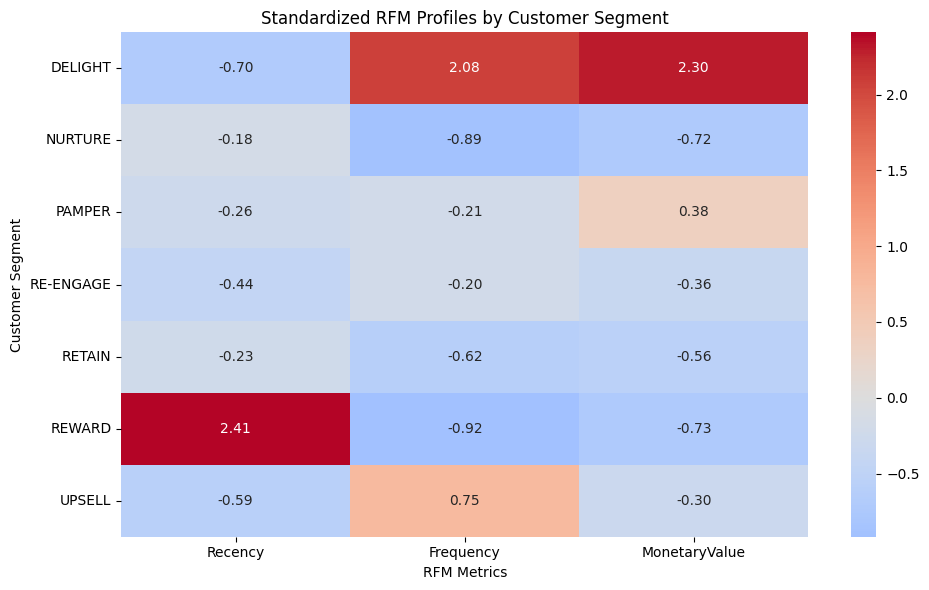

In [86]:
# Visualize standardized RFM profiles by customer segment

plt.figure(figsize=(10, 6))

sns.heatmap(
    profile_data,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Standardized RFM Profiles by Customer Segment")
plt.xlabel("RFM Metrics")
plt.ylabel("Customer Segment")
plt.tight_layout()
plt.show()

# Anomaly Detection

In [89]:
from sklearn.ensemble import IsolationForest
# Create the Isolation Forest model

iso_forest = IsolationForest(
    contamination=0.02,
    random_state=42
)
anomaly_labels = iso_forest.fit_predict(scaled_data)

print("Number of anomalies:", (anomaly_labels == -1).sum())
print("Number of normal observations:", (anomaly_labels == 1).sum())

Number of anomalies: 77
Number of normal observations: 3732


In [94]:
anomaly_by_cluster = pd.crosstab(
    full_clustering_df["ClusterLabel"],
    full_clustering_df["Anomaly"]
)

display(anomaly_by_cluster)

Anomaly,-1.00,1.00
ClusterLabel,,
NURTURE,0,1487
RE-ENGAGE,60,439
RETAIN,7,914
REWARD,10,892


In [95]:
anomalies_df = full_clustering_df[
    full_clustering_df["Anomaly"] == -1
]

anomalies_summary = anomalies_df.groupby("ClusterLabel").agg(
    Number_of_Anomalies=("Anomaly", "size"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_MonetaryValue=("MonetaryValue", "mean")
).round(2)

display(anomalies_summary)

,Number_of_Anomalies,Avg_Recency,Avg_Frequency,Avg_MonetaryValue
ClusterLabel,,,,
RE-ENGAGE,60,67.07,8.28,3102.47
RETAIN,7,175.57,2.00,2871.75
REWARD,10,294.60,3.30,1616.48


Les anomalies détectées sont principalement concentrées dans le segment RE-ENGAGE (60/77), où elles présentent une récence plus élevée mais également une fréquence et une valeur monétaire supérieures à la moyenne du segment. Les anomalies des segments RETAIN et REWARD présentent également une valeur monétaire nettement supérieure à celle de leurs segments respectifs, malgré une forte inactivité. Ces clients pourraient donc constituer des cibles prioritaires pour des campagnes de réactivation personnalisées.

In [96]:
pca_df["Anomaly"] = full_clustering_df.loc[pca_df.index, "Anomaly"]
pca_df["Anomaly"].value_counts()

Anomaly
 1.00    3732
-1.00      77
Name: count, dtype: int64

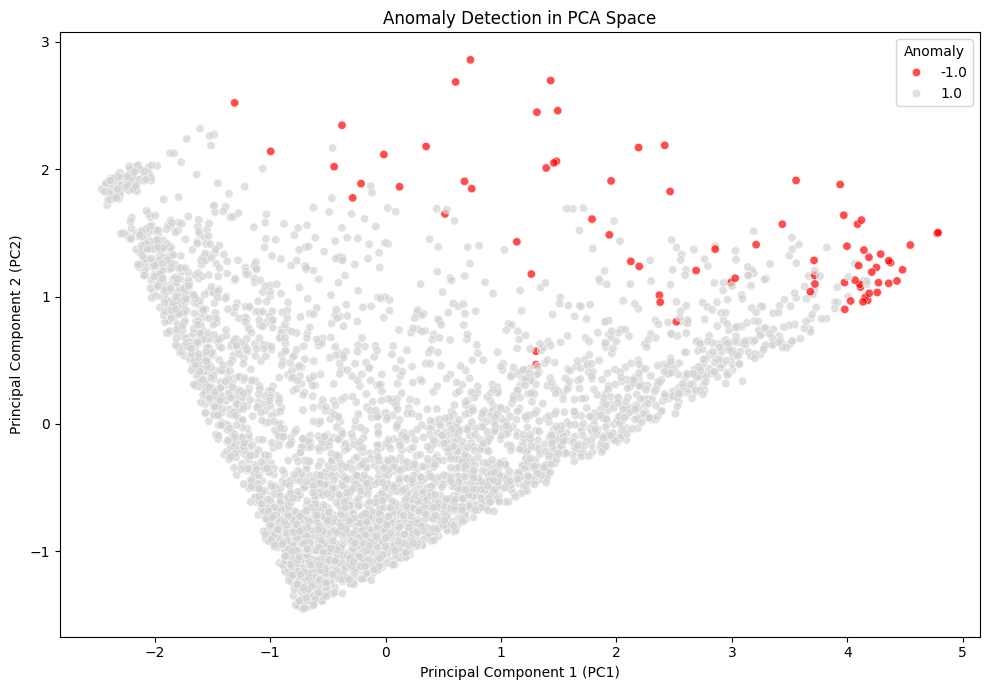

In [97]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Anomaly",
    palette={1: "lightgray", -1: "red"},
    alpha=0.7
)

plt.title("Anomaly Detection in PCA Space")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend(title="Anomaly")
plt.tight_layout()
plt.show()

# Business Recommendations


In [98]:
business_summary = cluster_summary.copy()

business_summary["Customer_Share"] = revenue_analysis["Customer_Share"]
business_summary["Revenue_Share"] = revenue_analysis["Revenue_Share"]

display(business_summary)

,Number_of_Customers,Avg_Recency,Avg_Frequency,Avg_MonetaryValue,Customer_Share,Revenue_Share
ClusterLabel,,,,,,
DELIGHT,226,14.45,25.87,17147.66,5.27,44.68
NURTURE,1487,53.96,1.64,413.62,34.70,7.09
PAMPER,197,47.91,7.19,6498.45,4.60,14.76
RE-ENGAGE,499,33.98,7.24,2426.36,11.65,13.96
RETAIN,921,49.99,3.88,1303.17,21.49,13.84
REWARD,902,251.17,1.43,384.54,21.05,4.00
UPSELL,53,23.08,15.04,2734.69,1.24,1.67


In [99]:
business_recommendations = pd.DataFrame({
    "ClusterLabel": [
        "DELIGHT",
        "PAMPER",
        "RE-ENGAGE",
        "RETAIN",
        "UPSELL",
        "NURTURE",
        "REWARD"
    ],
    
    "Strategy": [
        "Loyalty",
        "Premium Engagement",
        "Reactivation",
        "Retention",
        "Upselling",
        "Customer Development",
        "Win-back"
    ],
    
    "Recommendation": [
        "Protect and reward high-value loyal customers with VIP benefits and personalized offers.",
        "Maintain engagement through premium experiences, exclusive offers and personalized communication.",
        "Launch targeted reactivation campaigns to prevent valuable customers from becoming inactive.",
        "Increase purchase frequency through personalized promotions and loyalty incentives.",
        "Use cross-selling and upselling strategies to increase customer lifetime value.",
        "Develop engagement with targeted offers, product recommendations and incentives to increase purchase frequency.",
        "Target selectively with low-cost win-back campaigns and reactivate customers with potential value."
    ]
})

display(business_recommendations)

,ClusterLabel,Strategy,Recommendation
0,DELIGHT,Loyalty,Protect and reward high-value loyal customers ...
1,PAMPER,Premium Engagement,Maintain engagement through premium experience...
2,RE-ENGAGE,Reactivation,Launch targeted reactivation campaigns to prev...
3,RETAIN,Retention,Increase purchase frequency through personaliz...
4,UPSELL,Upselling,Use cross-selling and upselling strategies to ...
5,NURTURE,Customer Development,"Develop engagement with targeted offers, produ..."
6,REWARD,Win-back,Target selectively with low-cost win-back camp...


In [100]:
from sklearn.preprocessing import StandardScaler

priority_data = business_summary[
    ["Revenue_Share", "Avg_MonetaryValue", "Avg_Recency"]
].copy()

scaler_priority = StandardScaler()

priority_scaled = scaler_priority.fit_transform(priority_data)

priority_scores = pd.DataFrame(
    priority_scaled,
    columns=["Revenue_Share", "MonetaryValue", "Recency"],
    index=business_summary.index
)

display(priority_scores)

,Revenue_Share,MonetaryValue,Recency
ClusterLabel,,,
DELIGHT,2.28,2.30,-0.70
NURTURE,-0.54,-0.72,-0.18
PAMPER,0.04,0.38,-0.26
RE-ENGAGE,-0.02,-0.36,-0.44
RETAIN,-0.03,-0.56,-0.23
REWARD,-0.77,-0.73,2.41
UPSELL,-0.95,-0.30,-0.59


In [101]:
business_summary["Revenue_Contribution_Index"] = (
    business_summary["Revenue_Share"]
    / business_summary["Customer_Share"]
).round(2)

display(business_summary)

,Number_of_Customers,Avg_Recency,Avg_Frequency,Avg_MonetaryValue,Customer_Share,Revenue_Share,Revenue_Contribution_Index
ClusterLabel,,,,,,,
DELIGHT,226,14.45,25.87,17147.66,5.27,44.68,8.48
NURTURE,1487,53.96,1.64,413.62,34.70,7.09,0.20
PAMPER,197,47.91,7.19,6498.45,4.60,14.76,3.21
RE-ENGAGE,499,33.98,7.24,2426.36,11.65,13.96,1.20
RETAIN,921,49.99,3.88,1303.17,21.49,13.84,0.64
REWARD,902,251.17,1.43,384.54,21.05,4.00,0.19
UPSELL,53,23.08,15.04,2734.69,1.24,1.67,1.35


# Strategic Prioritization

In [102]:
strategic_priority = pd.DataFrame({
    "ClusterLabel": [
        "DELIGHT",
        "PAMPER",
        "RE-ENGAGE",
        "UPSELL",
        "RETAIN",
        "NURTURE",
        "REWARD"
    ],

    "Priority": [
        "CRITICAL",
        "HIGH",
        "HIGH",
        "HIGH",
        "MEDIUM",
        "MEDIUM",
        "LOW"
    ],

    "Business_Objective": [
        "Protect revenue",
        "Increase loyalty",
        "Reactivate valuable customers",
        "Increase customer value",
        "Improve retention",
        "Develop customer value",
        "Selective win-back"
    ]
})

display(strategic_priority)

,ClusterLabel,Priority,Business_Objective
0,DELIGHT,CRITICAL,Protect revenue
1,PAMPER,HIGH,Increase loyalty
2,RE-ENGAGE,HIGH,Reactivate valuable customers
3,UPSELL,HIGH,Increase customer value
4,RETAIN,MEDIUM,Improve retention
5,NURTURE,MEDIUM,Develop customer value
6,REWARD,LOW,Selective win-back


In [103]:
priority_analysis = business_summary.merge(
    strategic_priority,
    on="ClusterLabel"
)

display(priority_analysis)

,ClusterLabel,Number_of_Customers,Avg_Recency,Avg_Frequency,Avg_MonetaryValue,Customer_Share,Revenue_Share,Revenue_Contribution_Index,Priority,Business_Objective
0,DELIGHT,226,14.45,25.87,17147.66,5.27,44.68,8.48,CRITICAL,Protect revenue
1,NURTURE,1487,53.96,1.64,413.62,34.70,7.09,0.20,MEDIUM,Develop customer value
2,PAMPER,197,47.91,7.19,6498.45,4.60,14.76,3.21,HIGH,Increase loyalty
3,RE-ENGAGE,499,33.98,7.24,2426.36,11.65,13.96,1.20,HIGH,Reactivate valuable customers
4,RETAIN,921,49.99,3.88,1303.17,21.49,13.84,0.64,MEDIUM,Improve retention
5,REWARD,902,251.17,1.43,384.54,21.05,4.00,0.19,LOW,Selective win-back
6,UPSELL,53,23.08,15.04,2734.69,1.24,1.67,1.35,HIGH,Increase customer value


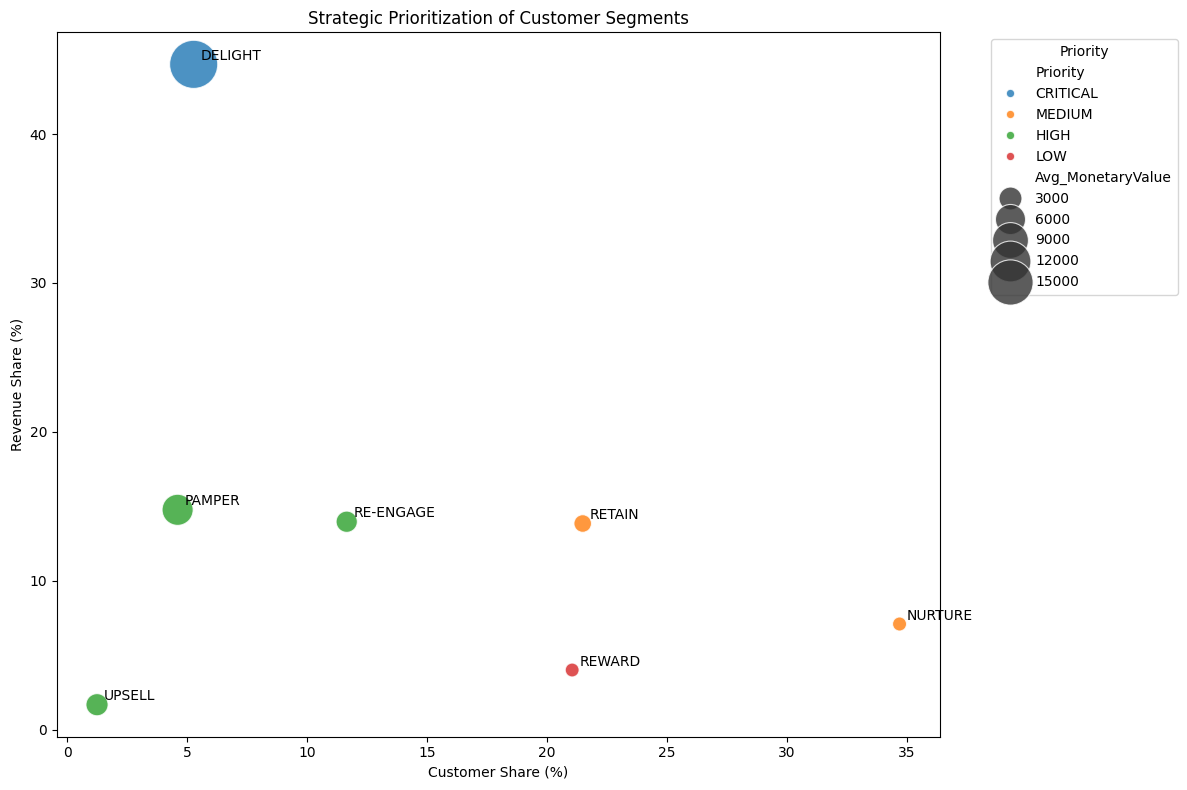

In [104]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=priority_analysis,
    x="Customer_Share",
    y="Revenue_Share",
    size="Avg_MonetaryValue",
    hue="Priority",
    sizes=(100, 1200),
    alpha=0.8
)

for _, row in priority_analysis.iterrows():
    plt.text(
        row["Customer_Share"] + 0.3,
        row["Revenue_Share"] + 0.3,
        row["ClusterLabel"],
        fontsize=10
    )

plt.title("Strategic Prioritization of Customer Segments")
plt.xlabel("Customer Share (%)")
plt.ylabel("Revenue Share (%)")
plt.legend(
    title="Priority",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# Executive Summary

In [105]:
executive_summary = priority_analysis[
    [
        "ClusterLabel",
        "Number_of_Customers",
        "Avg_Recency",
        "Avg_Frequency",
        "Avg_MonetaryValue",
        "Customer_Share",
        "Revenue_Share",
        "Revenue_Contribution_Index",
        "Priority",
        "Business_Objective"
    ]
].copy()

display(executive_summary)

,ClusterLabel,Number_of_Customers,Avg_Recency,Avg_Frequency,Avg_MonetaryValue,Customer_Share,Revenue_Share,Revenue_Contribution_Index,Priority,Business_Objective
0,DELIGHT,226,14.45,25.87,17147.66,5.27,44.68,8.48,CRITICAL,Protect revenue
1,NURTURE,1487,53.96,1.64,413.62,34.70,7.09,0.20,MEDIUM,Develop customer value
2,PAMPER,197,47.91,7.19,6498.45,4.60,14.76,3.21,HIGH,Increase loyalty
3,RE-ENGAGE,499,33.98,7.24,2426.36,11.65,13.96,1.20,HIGH,Reactivate valuable customers
4,RETAIN,921,49.99,3.88,1303.17,21.49,13.84,0.64,MEDIUM,Improve retention
5,REWARD,902,251.17,1.43,384.54,21.05,4.00,0.19,LOW,Selective win-back
6,UPSELL,53,23.08,15.04,2734.69,1.24,1.67,1.35,HIGH,Increase customer value


# Vérification et nettoyage du notebook

In [107]:
print("cluster_summary:", cluster_summary.shape)
print("revenue_analysis:", revenue_analysis.shape)
print("business_summary:", business_summary.shape)
print("priority_analysis:", priority_analysis.shape)
print("executive_summary:", executive_summary.shape)
executive_summary.isnull().sum()
display(executive_summary)
print(df.shape)

cluster_summary: (7, 4)
revenue_analysis: (7, 5)
business_summary: (7, 7)
priority_analysis: (7, 10)
executive_summary: (7, 10)


,ClusterLabel,Number_of_Customers,Avg_Recency,Avg_Frequency,Avg_MonetaryValue,Customer_Share,Revenue_Share,Revenue_Contribution_Index,Priority,Business_Objective
0,DELIGHT,226,14.45,25.87,17147.66,5.27,44.68,8.48,CRITICAL,Protect revenue
1,NURTURE,1487,53.96,1.64,413.62,34.70,7.09,0.20,MEDIUM,Develop customer value
2,PAMPER,197,47.91,7.19,6498.45,4.60,14.76,3.21,HIGH,Increase loyalty
3,RE-ENGAGE,499,33.98,7.24,2426.36,11.65,13.96,1.20,HIGH,Reactivate valuable customers
4,RETAIN,921,49.99,3.88,1303.17,21.49,13.84,0.64,MEDIUM,Improve retention
5,REWARD,902,251.17,1.43,384.54,21.05,4.00,0.19,LOW,Selective win-back
6,UPSELL,53,23.08,15.04,2734.69,1.24,1.67,1.35,HIGH,Increase customer value


(525461, 8)


## Conclusion

This project developed an end-to-end customer segmentation framework based on transactional retail data.

The analysis began with data cleaning and the construction of RFM features, capturing customer recency, purchase frequency and monetary value. After treating extreme values and standardizing the RFM features, K-Means clustering was applied to identify distinct customer segments. PCA was then used to visualize the resulting customer profiles in a reduced-dimensional space.

The analysis identified **7 customer segments**, each displaying distinct purchasing behaviors and business value. The revenue analysis revealed that a small proportion of customers can generate a disproportionately large share of total revenue. In particular, the **DELIGHT** segment represents only **5.27% of customers but contributes 44.68% of total revenue**, making it the most strategically critical segment.

Anomaly detection using **Isolation Forest** further identified unusual customer behaviors within the segments. These anomalies were not necessarily negative; some represented customers with unusually high monetary value combined with increasing inactivity, making them potential targets for targeted reactivation campaigns.

Finally, the segmentation results were translated into business strategies. High-value customers should be protected and rewarded, valuable inactive customers should be reactivated, growth-oriented segments should be targeted through upselling and personalized offers, while lower-value or highly inactive segments should be addressed through cost-effective retention and win-back campaigns.

Overall, this project demonstrates how **Data Science and Machine Learning can transform transactional customer data into actionable business insights**, moving from data preparation and unsupervised learning to customer profiling, anomaly detection and strategic decision-making.
